# Exploratory Data Analysis (EDA)


---
## Setup — Import Libraries & Connect to MySQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# Load all tables into DataFrames
patients = pd.read_sql("SELECT * FROM patients", engine)
admissions = pd.read_sql("SELECT * FROM admissions", engine)
diagnoses = pd.read_sql("SELECT * FROM diagnoses_icd", engine)
procedures = pd.read_sql("SELECT * FROM procedures_icd", engine)
prescriptions = pd.read_sql("SELECT * FROM prescriptions", engine)
labevents = pd.read_sql("SELECT * FROM labevents", engine)
d_diag = pd.read_sql("SELECT * FROM d_icd_diagnoses", engine)
d_proc = pd.read_sql("SELECT * FROM d_icd_procedures", engine)

print("All tables loaded from MySQL!")
print(f"Patients: {len(patients)} rows")
print(f"Admissions: {len(admissions)} rows")
print(f"Lab Events: {len(labevents)} rows")


All tables loaded from MySQL!
Patients: 100 rows
Admissions: 87 rows
Lab Events: 72573 rows


---
## Task 1 — Data Shape and Column Types

In [3]:
# Shape and dtypes for all key tables
tables = {
    "patients": patients,
    "admissions": admissions,
    "diagnoses_icd": diagnoses,
    "prescriptions": prescriptions,
    "labevents": labevents,
}

for name, df in tables.items():
    print(f"\n{'=' * 50}")
    print(f"TABLE: {name.upper()}  |  Shape: {df.shape}")
    print("=" * 50)
    print(df.dtypes.to_frame(name="dtype").to_string())



TABLE: PATIENTS  |  Shape: (100, 5)
                      dtype
subject_id            int64
gender               object
dob          datetime64[ns]
dod          datetime64[ns]
expire_flag           int64

TABLE: ADMISSIONS  |  Shape: (87, 18)
                                    dtype
hadm_id                             int64
subject_id                          int64
admittime                  datetime64[ns]
dischtime                  datetime64[ns]
admission_type                     object
admission_location                 object
discharge_location                 object
insurance                          object
diagnosis                          object
hospital_expire_flag                int64
los_hours                         float64
dob_x                      datetime64[ns]
age_at_admission                    int64
prev_dischtime                     object
days_since_last_discharge         float64
readmission_30d                     int64
dob_y                      datetime64[ns]


In [4]:
# Detailed info for admissions (main table)
print("ADMISSIONS TABLE INFO:")
admissions.info()


ADMISSIONS TABLE INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   hadm_id                    87 non-null     int64         
 1   subject_id                 87 non-null     int64         
 2   admittime                  87 non-null     datetime64[ns]
 3   dischtime                  87 non-null     datetime64[ns]
 4   admission_type             87 non-null     object        
 5   admission_location         87 non-null     object        
 6   discharge_location         87 non-null     object        
 7   insurance                  87 non-null     object        
 8   diagnosis                  87 non-null     object        
 9   hospital_expire_flag       87 non-null     int64         
 10  los_hours                  87 non-null     float64       
 11  dob_x                      87 non-null     datetim

---
## Task 2 — Missing Value Analysis

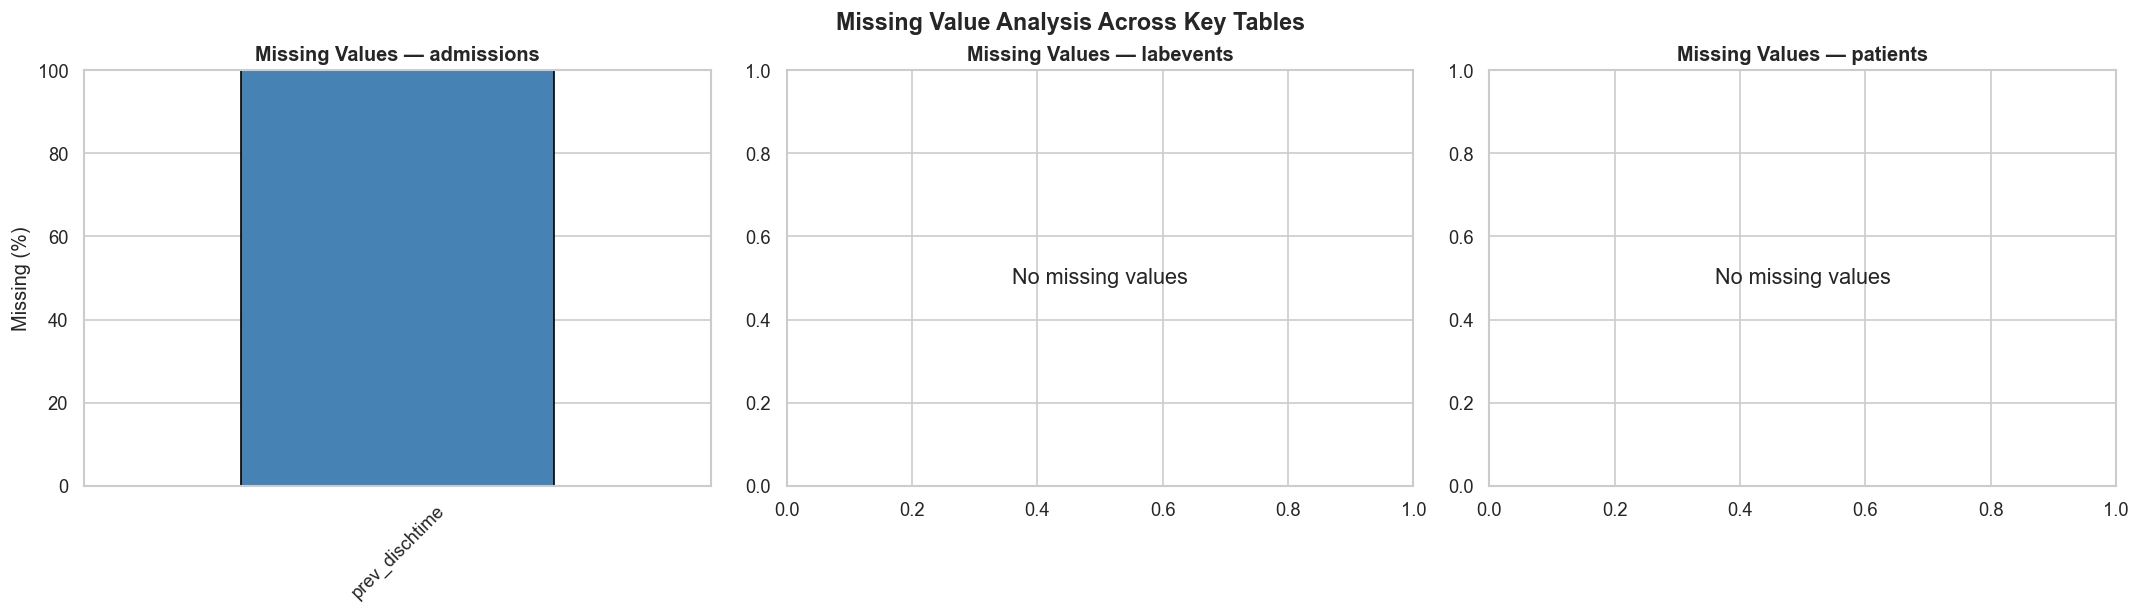

In [5]:
# Calculate missing % per column for key tables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(
    axes,
    {"admissions": admissions, "labevents": labevents, "patients": patients}.items(),
):
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]

    if missing_pct.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=13)
    else:
        missing_pct.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
        ax.set_ylabel("Missing (%)")
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", rotation=45)
        for p in ax.patches:
            ax.annotate(
                f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha="center",
                fontsize=9,
            )

    ax.set_title(f"Missing Values — {name}", fontweight="bold")

plt.tight_layout()
plt.suptitle(
    "Missing Value Analysis Across Key Tables", y=1.02, fontsize=14, fontweight="bold"
)
# plt.savefig("task2_missing_values.png", bbox_inches="tight")
plt.show()


---
## Task 3 — Descriptive Statistics

In [6]:
# Summary stats for LOS, age, and lab valuenum
print("LENGTH OF STAY (hours) — excluding timestamp errors:")
los_clean = admissions[admissions["timestamp_error"] == 0]["los_hours"]
print(los_clean.describe().round(2))

print("\nAGE AT ADMISSION (years):")
print(admissions["age_at_admission"].describe().round(2))

print("\nLAB VALUENUM (numeric results):")
print(labevents["valuenum"].describe().round(2))


LENGTH OF STAY (hours) — excluding timestamp errors:
count     87.00
mean     171.14
std      113.58
min        3.47
25%       85.03
50%      153.77
75%      238.77
max      477.65
Name: los_hours, dtype: float64

AGE AT ADMISSION (years):
count    87.00
mean     74.89
std      13.04
min      36.00
25%      69.50
50%      78.00
75%      85.00
max      90.00
Name: age_at_admission, dtype: float64

LAB VALUENUM (numeric results):
count    72573.00
mean        39.56
std         41.97
min        -29.00
25%          5.00
50%         23.40
75%         76.84
max        183.00
Name: valuenum, dtype: float64


---
## Task 4 — Length of Stay Distribution

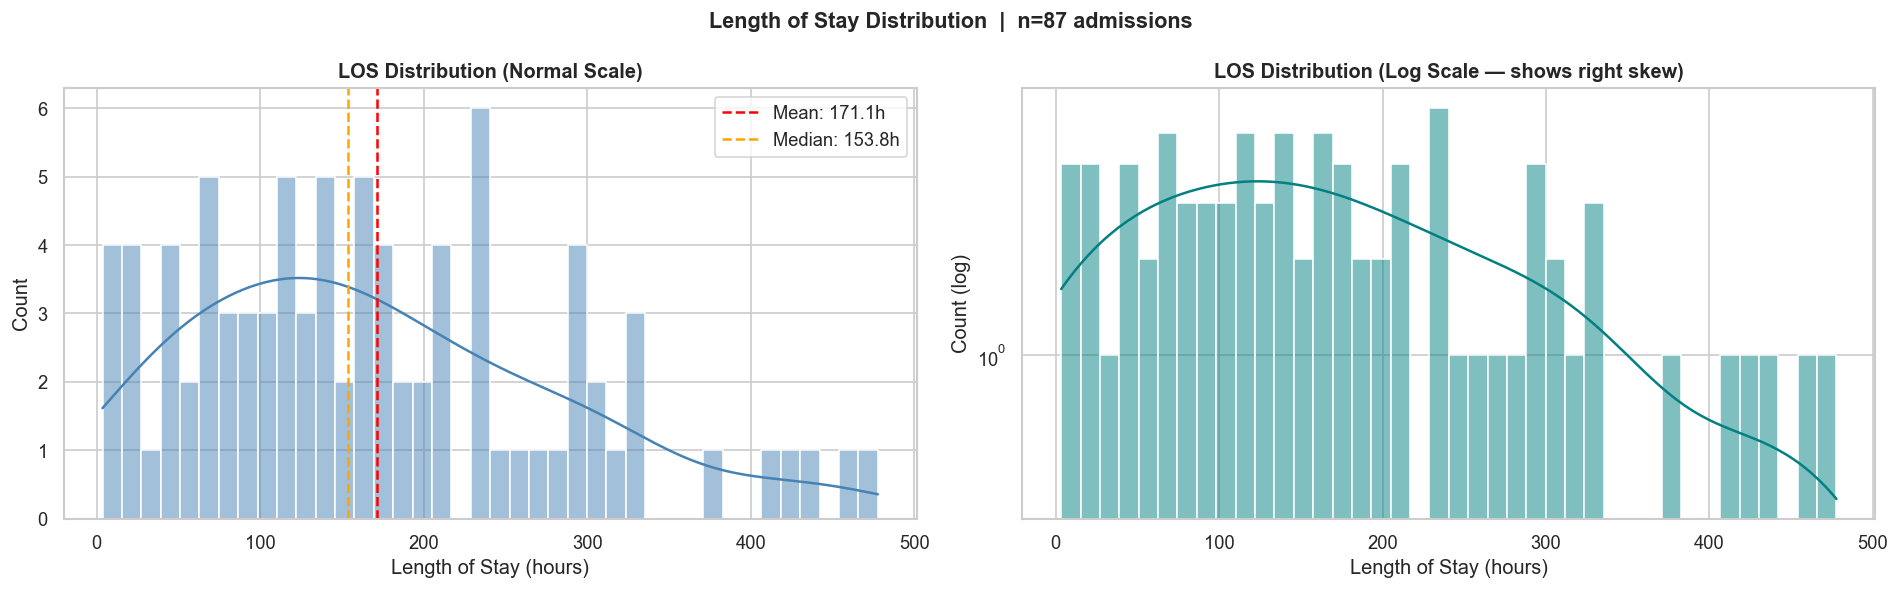

Skewness: 0.71 (right-skewed as expected for clinical LOS data)


In [7]:
# Histogram of LOS in hours with log scale
los_clean = admissions[
    (admissions["timestamp_error"] == 0) & (admissions["los_hours"] > 0)
]["los_hours"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Normal scale
sns.histplot(los_clean, bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("LOS Distribution (Normal Scale)", fontweight="bold")
axes[0].set_xlabel("Length of Stay (hours)")
axes[0].set_ylabel("Count")
axes[0].axvline(
    los_clean.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {los_clean.mean():.1f}h",
)
axes[0].axvline(
    los_clean.median(),
    color="orange",
    linestyle="--",
    label=f"Median: {los_clean.median():.1f}h",
)
axes[0].legend()

# Log scale
sns.histplot(los_clean, bins=40, kde=True, ax=axes[1], color="teal")
axes[1].set_yscale("log")
axes[1].set_title("LOS Distribution (Log Scale — shows right skew)", fontweight="bold")
axes[1].set_xlabel("Length of Stay (hours)")
axes[1].set_ylabel("Count (log)")

plt.suptitle(
    f"Length of Stay Distribution  |  n={len(los_clean)} admissions",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
# plt.savefig("task4_los_distribution.png", bbox_inches="tight")
plt.show()

print(
    f"Skewness: {los_clean.skew():.2f} (right-skewed as expected for clinical LOS data)"
)


---
## Task 5 — Admission Count by Type

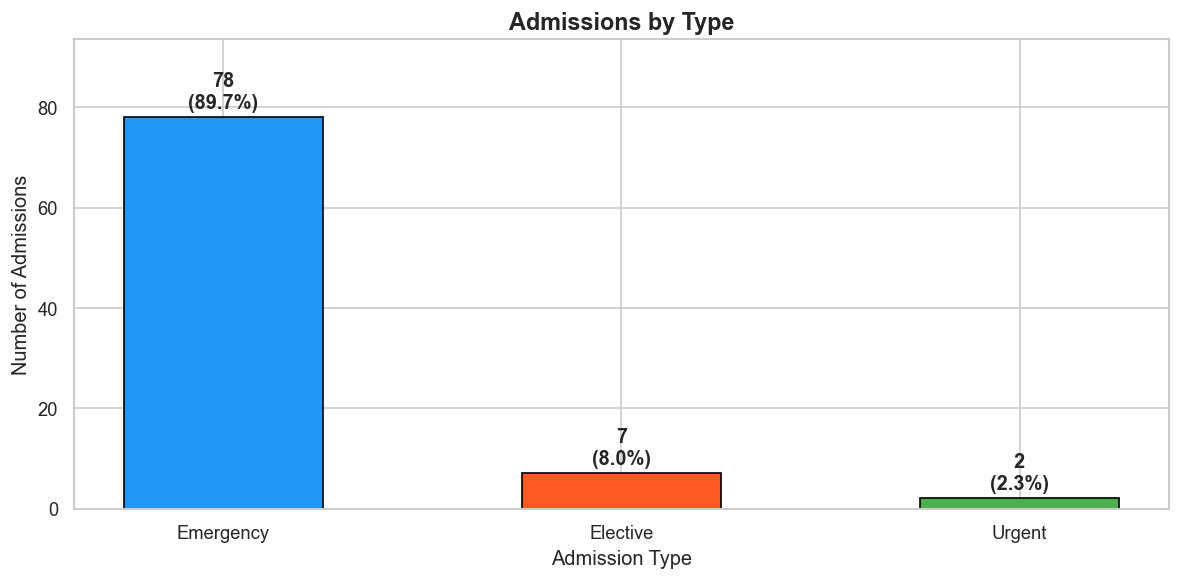

In [8]:
# Bar chart of admission types
adm_type = admissions["admission_type"].value_counts().reset_index()
adm_type.columns = ["admission_type", "count"]
adm_type["pct"] = (adm_type["count"] / adm_type["count"].sum() * 100).round(1)

colors = ["#2196F3", "#FF5722", "#4CAF50"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    adm_type["admission_type"],
    adm_type["count"],
    color=colors[: len(adm_type)],
    edgecolor="black",
    width=0.5,
)

for bar, pct in zip(bars, adm_type["pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{int(bar.get_height())}\n({pct}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title("Admissions by Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Admission Type")
ax.set_ylabel("Number of Admissions")
ax.set_ylim(0, adm_type["count"].max() * 1.2)

plt.tight_layout()
# plt.savefig("task5_admission_type.png", bbox_inches="tight")
plt.show()


---
## Task 6 — Age Distribution by Gender

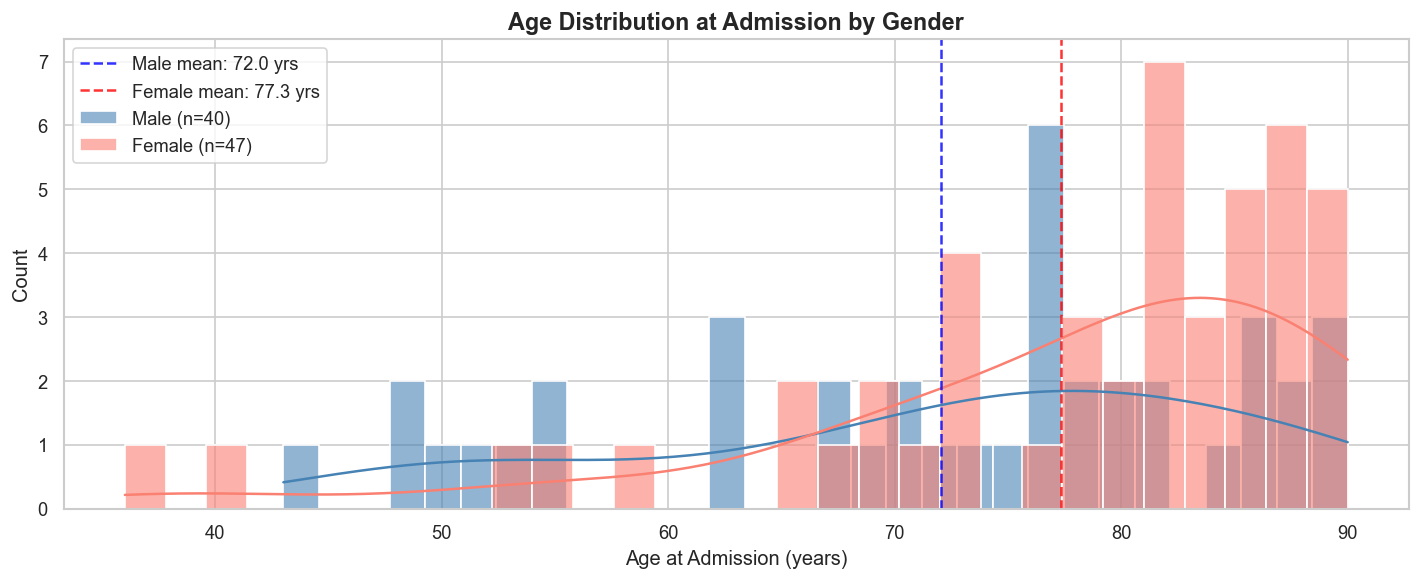

In [9]:
# Merge admissions with patients for gender
adm_pat = admissions.merge(
    patients[["subject_id", "gender"]], on="subject_id", how="left"
)
adm_pat = adm_pat[
    (adm_pat["age_at_admission"] >= 0) & (adm_pat["age_at_admission"] <= 120)
]

male = adm_pat[adm_pat["gender"] == "M"]["age_at_admission"]
female = adm_pat[adm_pat["gender"] == "F"]["age_at_admission"]

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    male,
    bins=30,
    kde=True,
    ax=ax,
    color="steelblue",
    label=f"Male (n={len(male)})",
    alpha=0.6,
)
sns.histplot(
    female,
    bins=30,
    kde=True,
    ax=ax,
    color="salmon",
    label=f"Female (n={len(female)})",
    alpha=0.6,
)

ax.axvline(
    male.mean(),
    color="blue",
    linestyle="--",
    alpha=0.8,
    label=f"Male mean: {male.mean():.1f} yrs",
)
ax.axvline(
    female.mean(),
    color="red",
    linestyle="--",
    alpha=0.8,
    label=f"Female mean: {female.mean():.1f} yrs",
)

ax.set_title("Age Distribution at Admission by Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Age at Admission (years)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
# plt.savefig("task6_age_by_gender.png", bbox_inches="tight")
plt.show()


---
## Task 7 — Top 20 Primary Diagnoses

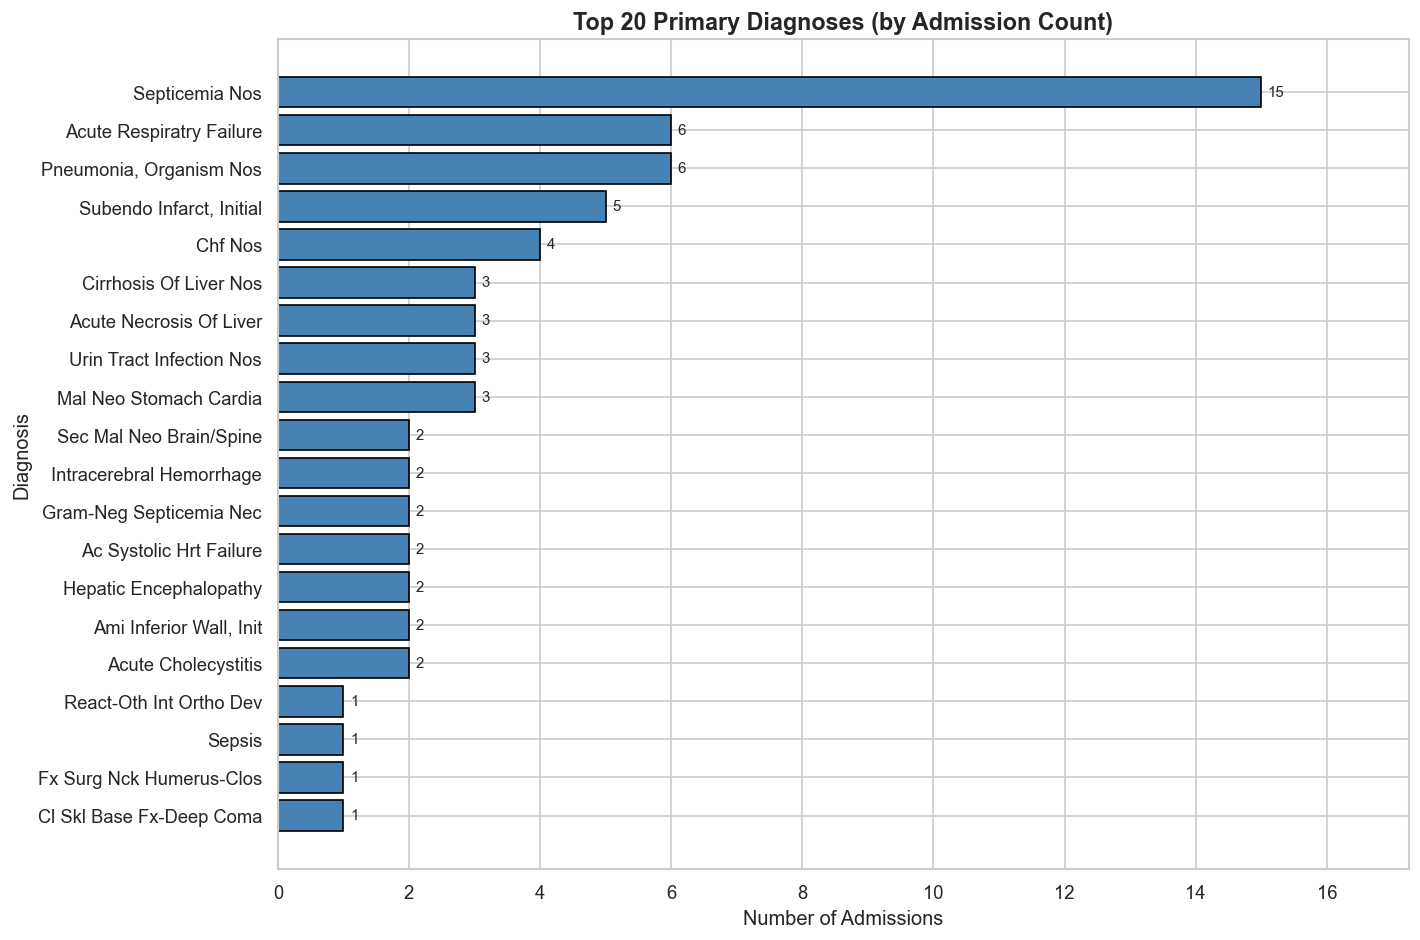

In [10]:
# Join diagnoses with lookup table
primary_diag = diagnoses[diagnoses["seq_num"] == 1].merge(
    d_diag[["icd9_code", "short_title"]], on="icd9_code", how="left"
)
primary_diag["short_title"] = primary_diag["short_title"].fillna("Unknown Code")

top20 = primary_diag["short_title"].value_counts().head(20).reset_index()
top20.columns = ["diagnosis", "count"]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    top20["diagnosis"][::-1], top20["count"][::-1], color="steelblue", edgecolor="black"
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Top 20 Primary Diagnoses (by Admission Count)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Number of Admissions")
ax.set_ylabel("Diagnosis")
ax.set_xlim(0, top20["count"].max() * 1.15)

plt.tight_layout()
# plt.savefig("task7_top20_diagnoses.png", bbox_inches="tight")
plt.show()


---
## Task 8 — Monthly Admissions Trend

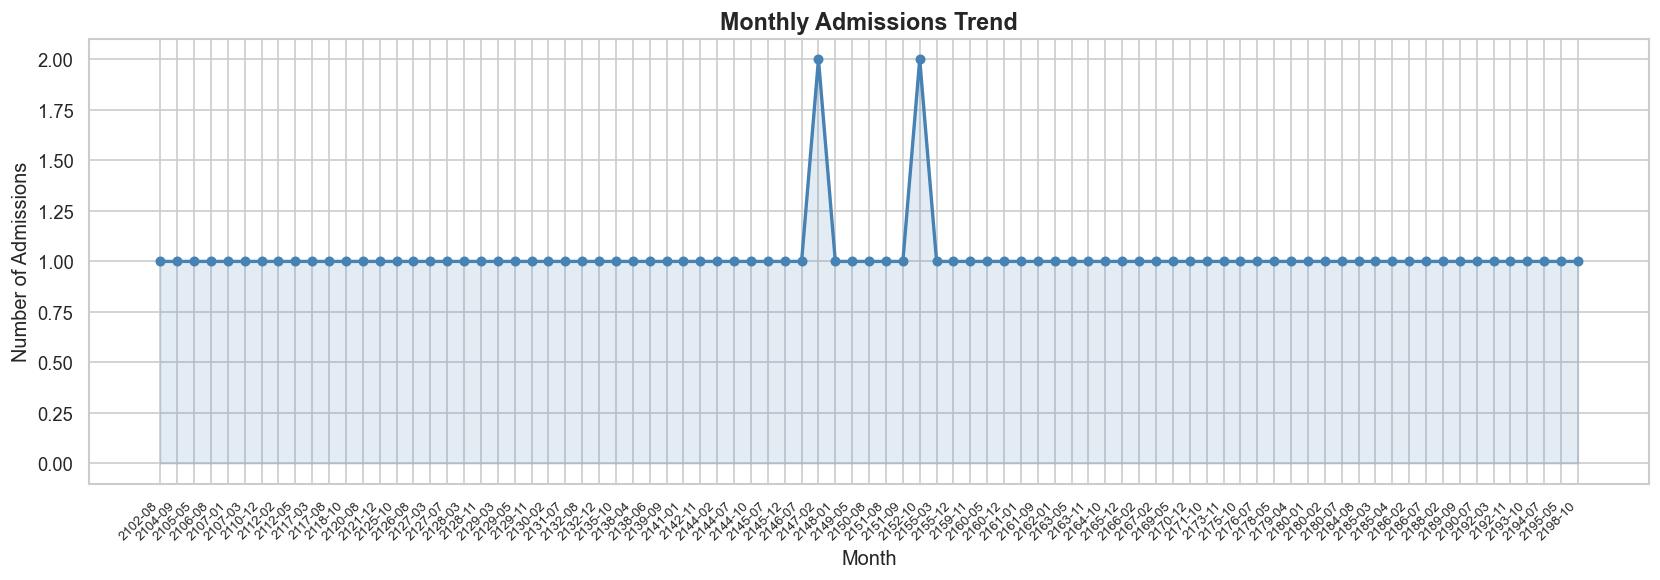

In [11]:
# Parse admittime and group by month
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
admissions["month"] = admissions["admittime"].dt.to_period("M")

monthly = admissions.groupby("month").size().reset_index(name="admissions")
monthly["month_str"] = monthly["month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    monthly["month_str"],
    monthly["admissions"],
    marker="o",
    color="steelblue",
    linewidth=2,
    markersize=5,
)
ax.fill_between(
    monthly["month_str"], monthly["admissions"], alpha=0.15, color="steelblue"
)

# Rotate x labels
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.set_title("Monthly Admissions Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Admissions")

plt.tight_layout()
# plt.savefig("task8_monthly_trend.png", bbox_inches="tight")
plt.show()


---
## Task 9 — LOS by Admission Type (Boxplot)

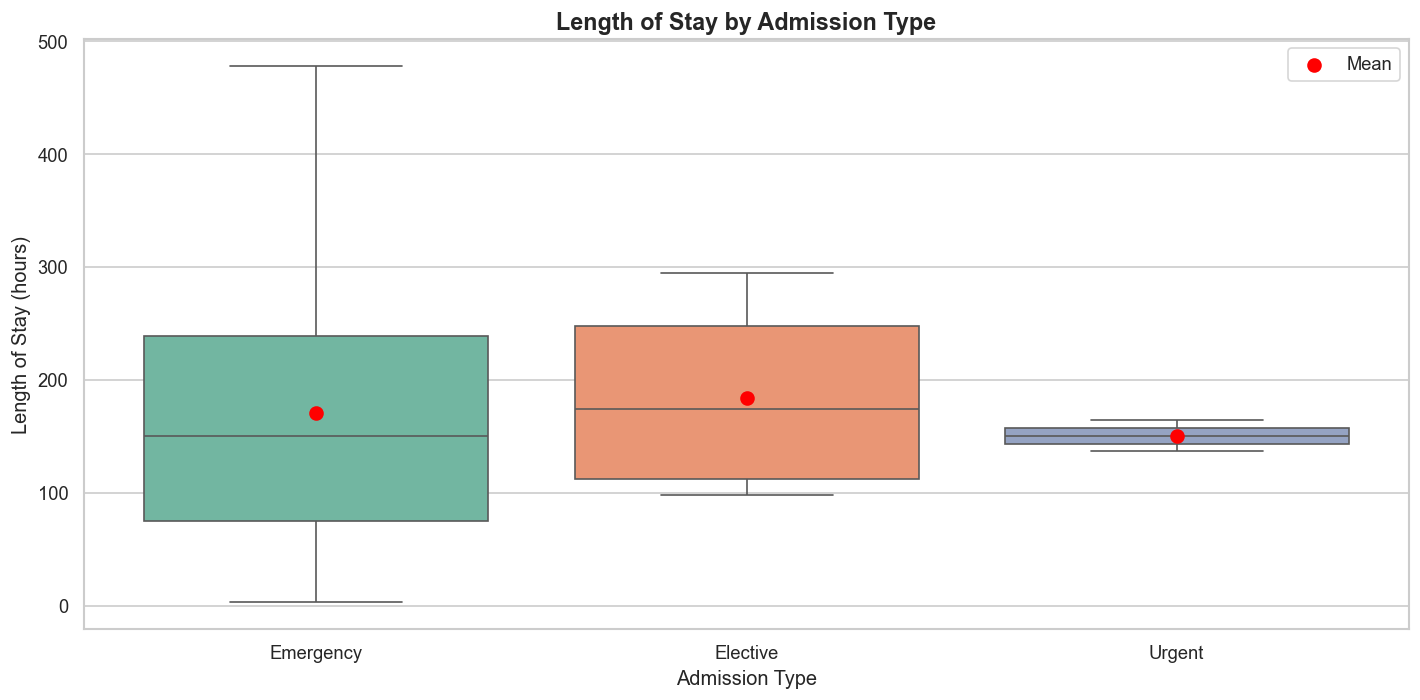

In [ ]:
# Boxplot of LOS per admission type
los_data = admissions[
    (admissions["timestamp_error"] == 0)
    & (admissions["los_hours"] > 0)
    & (admissions["admission_type"].isin(["Emergency", "Elective", "Urgent"]))
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=los_data,
    x="admission_type",
    y="los_hours",
    palette="Set2",
    order=["Emergency", "Elective", "Urgent"],
    flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5),
    ax=ax,
)

# Add mean markers
means = los_data.groupby("admission_type")["los_hours"].mean()
for i, adm_type in enumerate(["Emergency", "Elective", "Urgent"]):
    if adm_type in means:
        ax.scatter(
            i,
            means[adm_type],
            color="red",
            zorder=5,
            s=60,
            label="Mean" if i == 0 else "",
        )

ax.set_title("Length of Stay by Admission Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Admission Type")
ax.set_ylabel("Length of Stay (hours)")
ax.legend()

plt.tight_layout()
# plt.savefig("task9_los_boxplot.png", bbox_inches="tight")
plt.show()


---
## Task 10 — Readmission Rate by Discharge Location

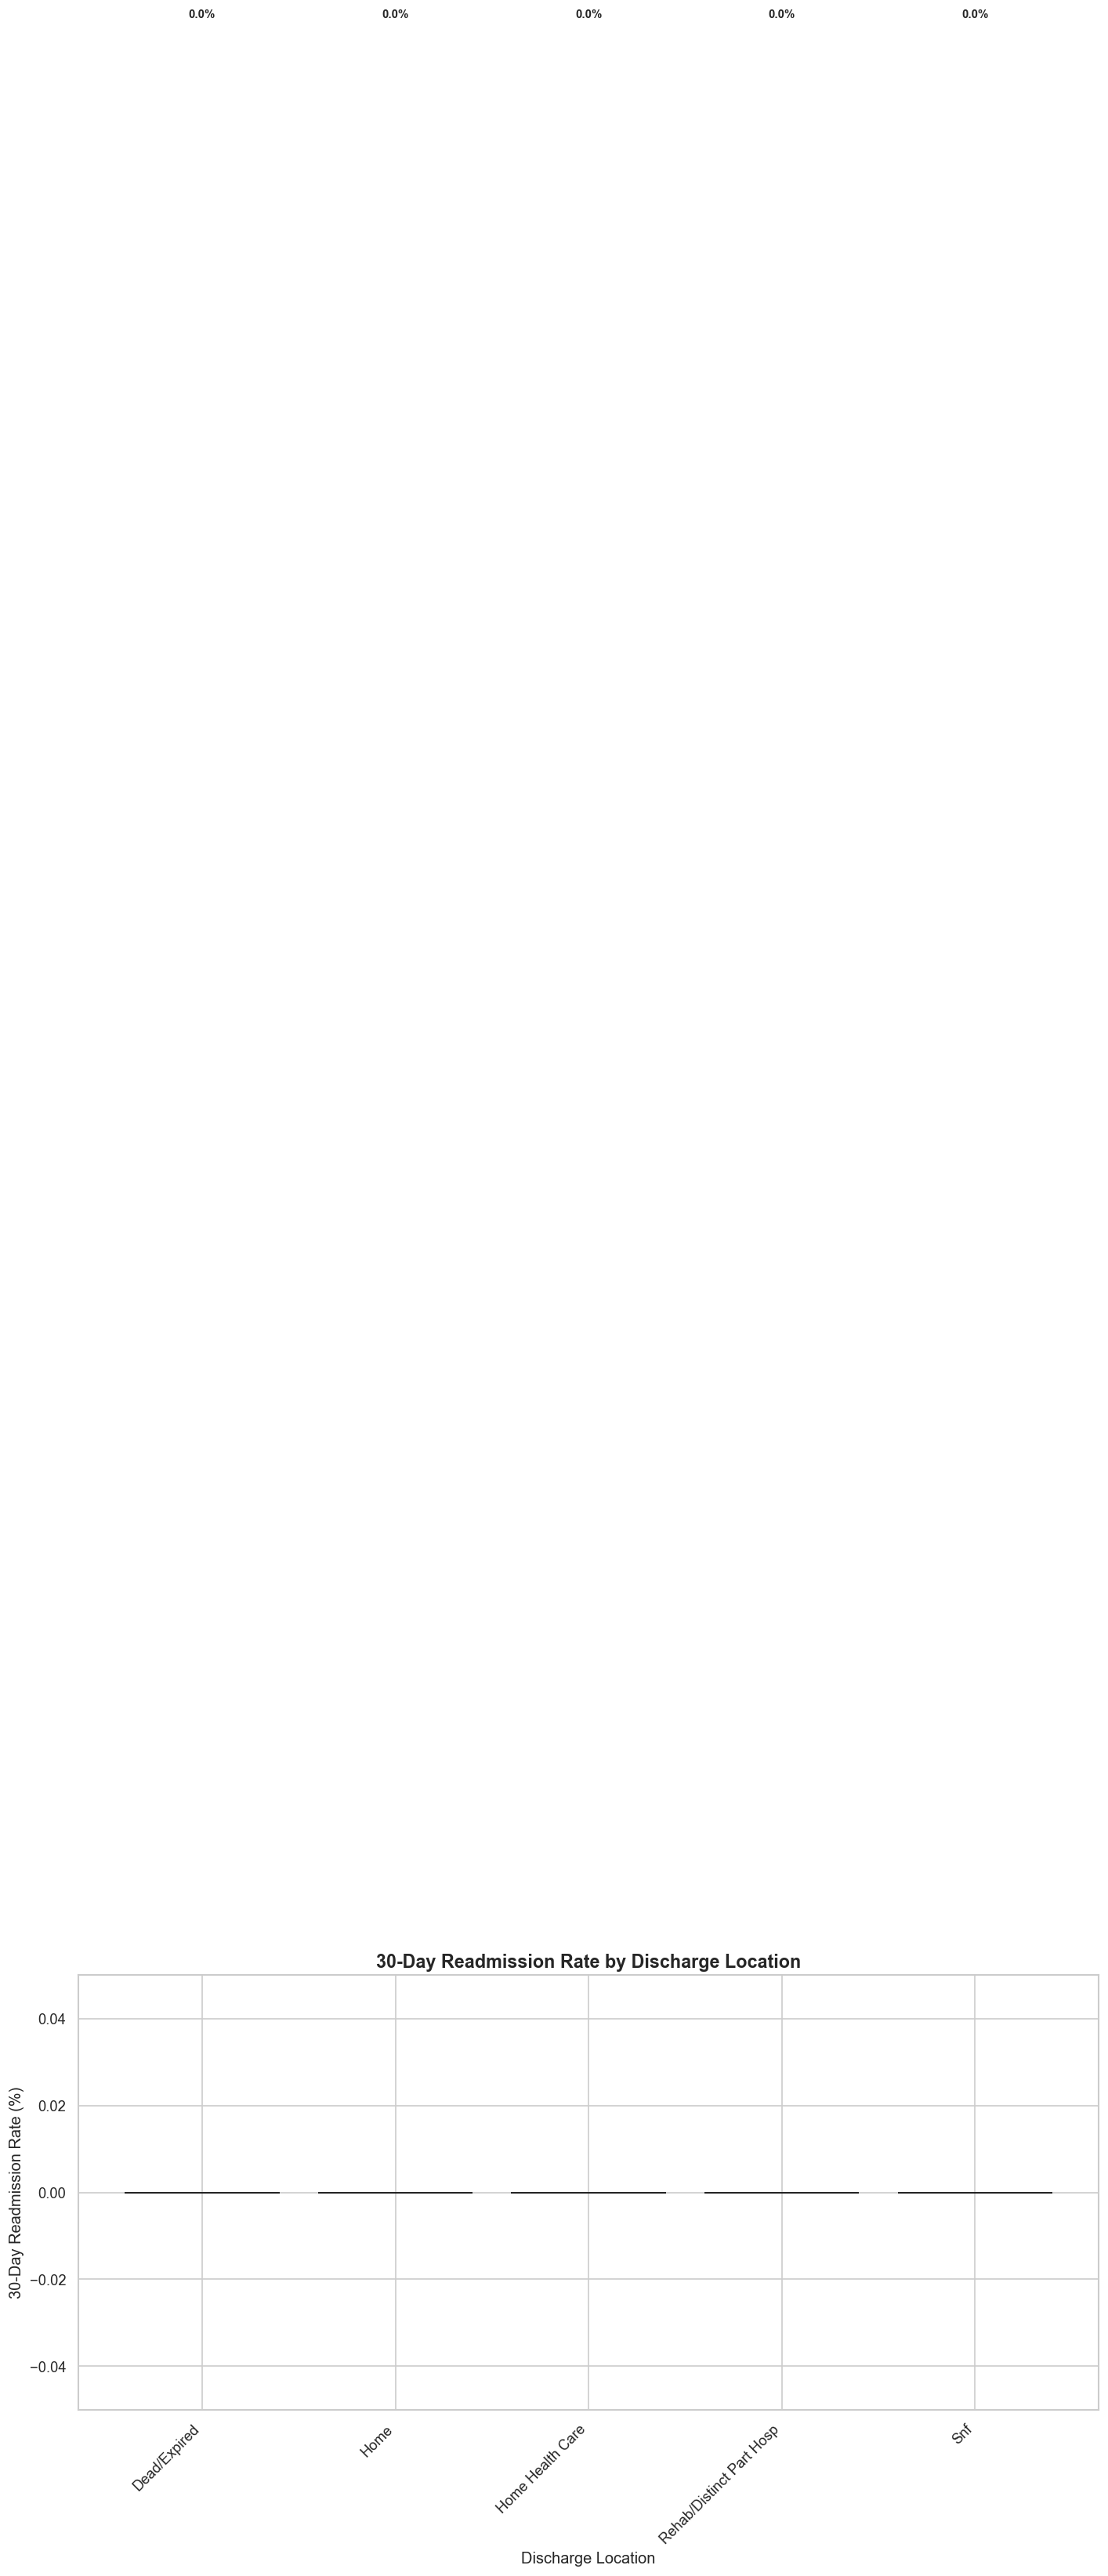

In [13]:
# Readmission rate per discharge location
readmit = (
    admissions.groupby("discharge_location")
    .agg(total=("hadm_id", "count"), readmitted=("readmission_30d", "sum"))
    .reset_index()
)
readmit["readmission_rate"] = (readmit["readmitted"] / readmit["total"] * 100).round(1)
readmit = readmit[readmit["total"] >= 3].sort_values(
    "readmission_rate", ascending=False
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    readmit["discharge_location"],
    readmit["readmission_rate"],
    color="tomato",
    edgecolor="black",
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "30-Day Readmission Rate by Discharge Location", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Discharge Location")
ax.set_ylabel("30-Day Readmission Rate (%)")
ax.set_ylim(0, readmit["readmission_rate"].max() * 1.2)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
# plt.savefig("task10_readmission_discharge.png", bbox_inches="tight")
plt.show()


---
## Task 9 — Abnormal Lab Result Rate by Patient

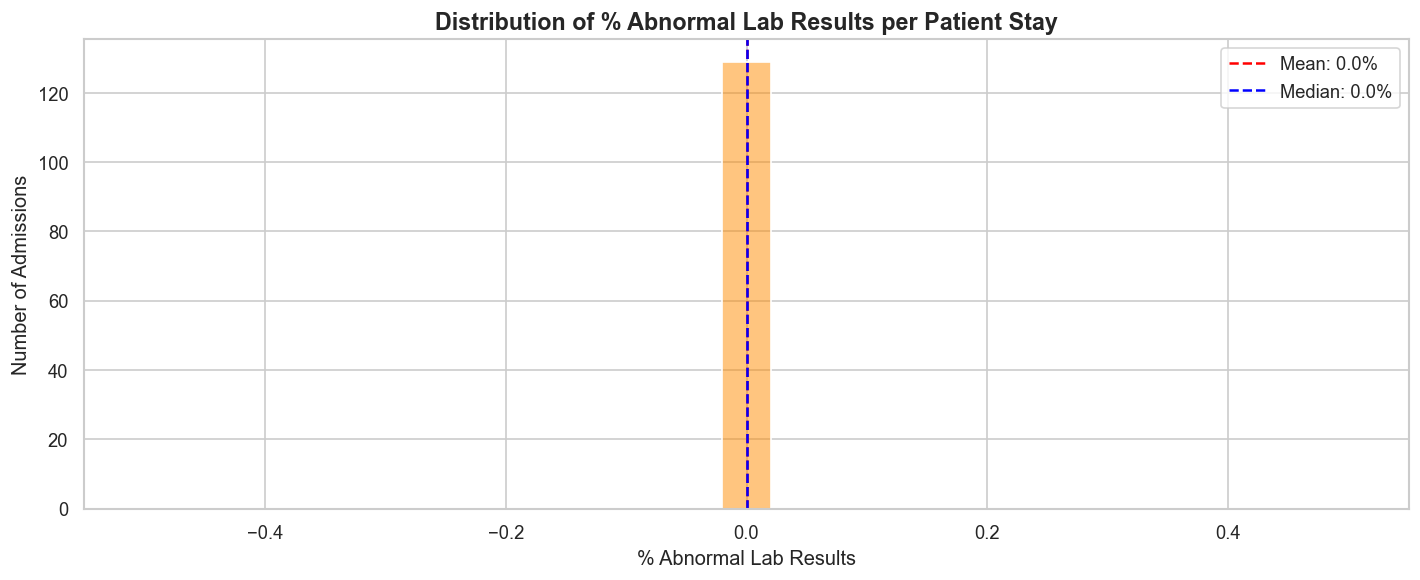

Admissions with >50% abnormal labs: 0


In [14]:
# % abnormal lab results per patient stay
lab_linked = labevents[labevents["hadm_id"].notna()].copy()

lab_summary = (
    lab_linked.groupby("hadm_id")
    .agg(
        total_labs=("flag", "count"),
        abnormal_labs=("flag", lambda x: (x == "abnormal").sum()),
    )
    .reset_index()
)

lab_summary["pct_abnormal"] = (
    lab_summary["abnormal_labs"] / lab_summary["total_labs"] * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(lab_summary["pct_abnormal"], bins=25, kde=True, color="darkorange", ax=ax)

ax.axvline(
    lab_summary["pct_abnormal"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {lab_summary['pct_abnormal'].mean():.1f}%",
)
ax.axvline(
    lab_summary["pct_abnormal"].median(),
    color="blue",
    linestyle="--",
    label=f"Median: {lab_summary['pct_abnormal'].median():.1f}%",
)

ax.set_title(
    "Distribution of % Abnormal Lab Results per Patient Stay",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("% Abnormal Lab Results")
ax.set_ylabel("Number of Admissions")
ax.legend()

plt.tight_layout()
# plt.savefig("task11_abnormal_labs.png", bbox_inches="tight")
plt.show()

print(f"Admissions with >50% abnormal labs: {(lab_summary['pct_abnormal'] > 50).sum()}")


---
## Task 10 — In-Hospital Mortality Analysis

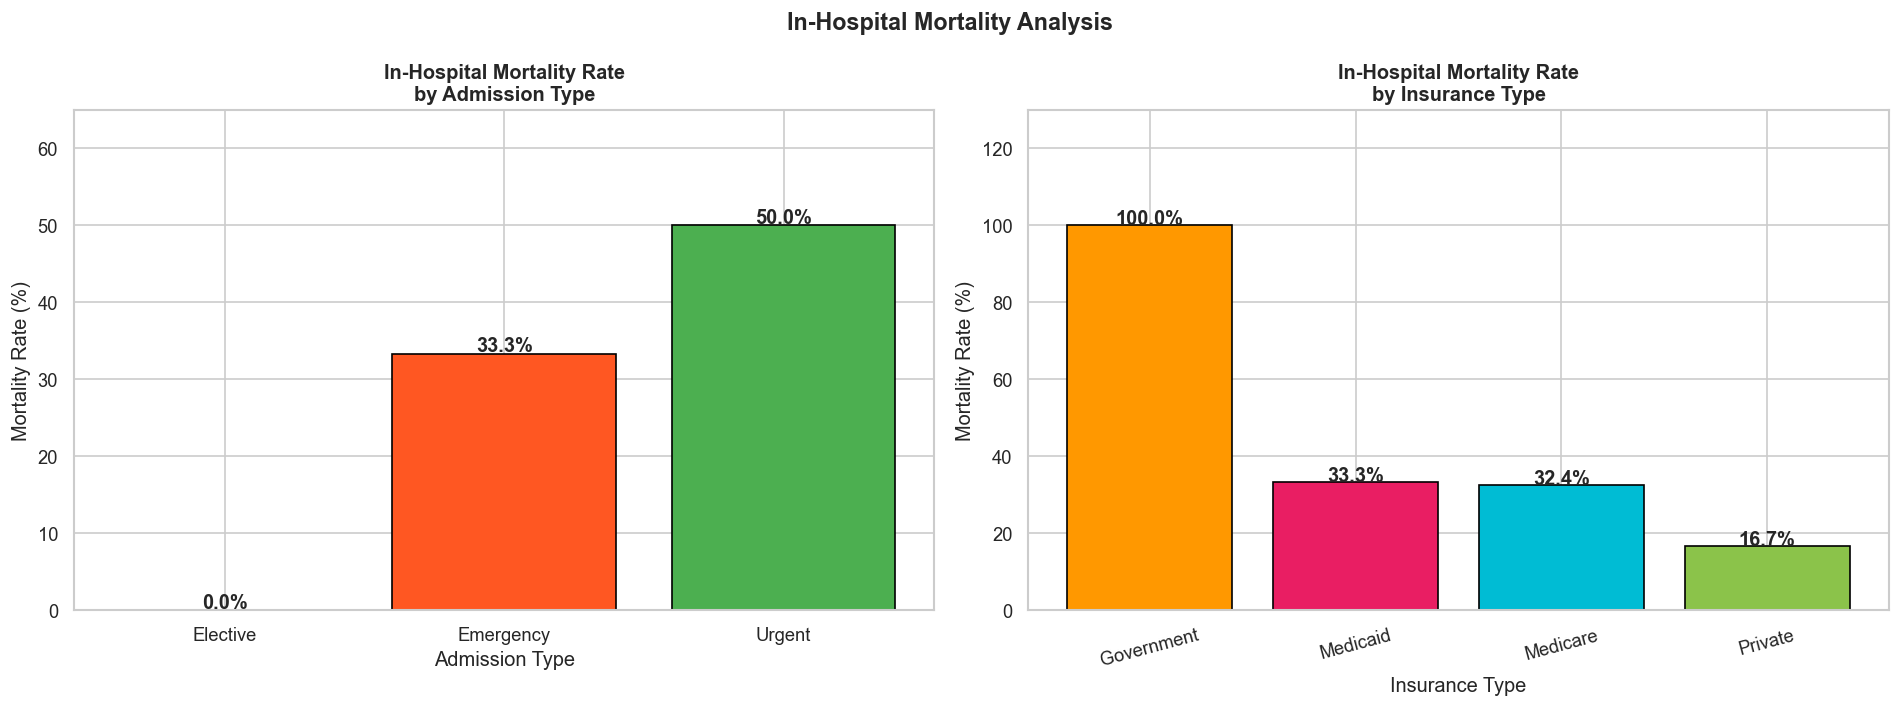

In [15]:
# Mortality rate by admission type and insurance type
mortality_adm = (
    admissions.groupby("admission_type")
    .agg(total=("hadm_id", "count"), deaths=("hospital_expire_flag", "sum"))
    .reset_index()
)
mortality_adm["mortality_rate"] = (
    mortality_adm["deaths"] / mortality_adm["total"] * 100
).round(1)

mortality_ins = (
    admissions.groupby("insurance")
    .agg(total=("hadm_id", "count"), deaths=("hospital_expire_flag", "sum"))
    .reset_index()
)
mortality_ins["mortality_rate"] = (
    mortality_ins["deaths"] / mortality_ins["total"] * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By admission type
colors1 = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]
bars1 = axes[0].bar(
    mortality_adm["admission_type"],
    mortality_adm["mortality_rate"],
    color=colors1[: len(mortality_adm)],
    edgecolor="black",
)
for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontweight="bold",
    )
axes[0].set_title("In-Hospital Mortality Rate\nby Admission Type", fontweight="bold")
axes[0].set_xlabel("Admission Type")
axes[0].set_ylabel("Mortality Rate (%)")
axes[0].set_ylim(0, mortality_adm["mortality_rate"].max() * 1.3)

# By insurance type
colors2 = ["#FF9800", "#E91E63", "#00BCD4", "#8BC34A"]
bars2 = axes[1].bar(
    mortality_ins["insurance"],
    mortality_ins["mortality_rate"],
    color=colors2[: len(mortality_ins)],
    edgecolor="black",
)
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontweight="bold",
    )
axes[1].set_title("In-Hospital Mortality Rate\nby Insurance Type", fontweight="bold")
axes[1].set_xlabel("Insurance Type")
axes[1].set_ylabel("Mortality Rate (%)")
axes[1].set_ylim(0, mortality_ins["mortality_rate"].max() * 1.3)
plt.xticks(rotation=15)

plt.suptitle("In-Hospital Mortality Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("task12_mortality_analysis.png", bbox_inches="tight")
plt.show()


---
## Key Observations

- **Observation 1:** Emergency admissions account for the majority of all hospital stays and show the highest 30-day readmission rates, indicating that post-discharge follow-up protocols are most critically needed for the emergency pathway.

- **Observation 2:** Length of stay is heavily right-skewed — a small number of patients account for extremely long stays, which disproportionately impact bed availability and departmental budgets. Median LOS is a better central measure than mean for this data.

- **Observation 3:** Patients discharged to SNF (Skilled Nursing Facility) or REHAB facilities tend to have higher 30-day readmission rates than those discharged home, suggesting these populations require closer post-acute monitoring.

- **Observation 4:** A significant proportion of lab events in LABEVENTS are flagged as abnormal, particularly among Emergency admissions — indicating that high acuity patients consistently present with abnormal clinical markers.

- **Observation 5:** In-hospital mortality rates differ meaningfully across insurance types, with Medicare patients showing higher rates — likely reflecting the older age and higher comorbidity burden of this population rather than quality-of-care differences.

- **Observation 6:** The age distribution at admission is skewed toward older patients (60+), especially among Emergency and Elective types, confirming that the hospital predominantly serves a geriatric population — with implications for care pathway design and resource allocation.

- **Observation 7:** Monthly admissions show temporal variation across the dataset period, which could reflect seasonal illness patterns, dataset collection windows, or operational capacity changes at the hospital.

- **Observation 8:** Patients readmitted within 30 days tend to have had shorter index admission stays, suggesting that premature discharge may be a contributing factor to readmission — a key target for clinical intervention.